In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
import joblib
from sklearn.base import clone

In [ ]:
# =========================
# 1. Paths
# =========================

BASE_DIR = "/content/drive/MyDrive/Senior_Project/00_Data/cleaned/Final_Short_Form"

PATHS = {
    "liar": {
        "train": f"{BASE_DIR}/LIAR/train_liar.csv",
        "test": f"{BASE_DIR}/LIAR/test_liar.csv",
    },
    "covid": {
        "train": f"{BASE_DIR}/COVID/train_covid.csv",
        "test": f"{BASE_DIR}/COVID/test_covid.csv",
    },
    "sensational": {
        "train": f"{BASE_DIR}/Sensational/train_sensational.csv",
        "test": f"{BASE_DIR}/Sensational/test_sensational.csv",
    },
    "baseline": {
        "train": f"{BASE_DIR}/LIAR+COVID/train_liar_covid.csv",
        "test": f"{BASE_DIR}/LIAR+COVID/test_liar_covid.csv",
    },
    "combined": {
        "train": f"{BASE_DIR}/Combined/train_combined.csv",
        "test": f"{BASE_DIR}/Combined/test_combined.csv",
    }
}

OUT_DIR = "/content/drive/MyDrive/Senior_Project/03_Results/Baselines/Short_Form"
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
# =========================
# 2. Helper functions
# =========================

def load_split(train_path, test_path):
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    train_df = train_df.dropna(subset=["text", "is_fake"]).copy()
    test_df = test_df.dropna(subset=["text", "is_fake"]).copy()

    train_df["text"] = train_df["text"].astype(str).str.strip()
    test_df["text"] = test_df["text"].astype(str).str.strip()

    train_df = train_df[train_df["text"] != ""]
    test_df = test_df[test_df["text"] != ""]

    train_df["is_fake"] = train_df["is_fake"].astype(int)
    test_df["is_fake"] = test_df["is_fake"].astype(int)

    return train_df, test_df


def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

def clean_text_basic(text):
    text = text.lower()
    text = text.replace("[entity]", "")
    return text

def run_tfidf_eval(train_df, test_df, train_name, test_name, clf_name, clf):
    X_train = train_df["text"]
    y_train = train_df["is_fake"]

    X_test = test_df["text"]
    y_test = test_df["is_fake"]

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            preprocessor=clean_text_basic,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9,
            max_features=10000
        )),
        ("clf", clf)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    metrics = compute_metrics(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n=== Train: {train_name} | Test: {test_name} | Model: {clf_name} ===")
    print(metrics)
    print("Confusion matrix:")
    print(cm)

    return {
        "train_dataset": train_name,
        "test_dataset": test_name,
        "model": clf_name,
        **metrics,
        "tn": cm[0][0],
        "fp": cm[0][1],
        "fn": cm[1][0],
        "tp": cm[1][1],
    }, pipe

In [ ]:
# =========================
# 3. Load all splits
# =========================

datasets = {}

for name, paths in PATHS.items():
    train_df, test_df = load_split(paths["train"], paths["test"])
    datasets[name] = {
        "train": train_df,
        "test": test_df
    }

    print(f"\n{name}")
    print("Train:", train_df.shape)
    print("Test:", test_df.shape)
    print("Train labels:")
    print(train_df["is_fake"].value_counts())
    print("Test labels:")
    print(test_df["is_fake"].value_counts())


liar
Train: (8636, 17)
Test: (2160, 17)
Train labels:
is_fake
0    4919
1    3717
Name: count, dtype: int64
Test labels:
is_fake
0    1230
1     930
Name: count, dtype: int64

covid
Train: (7679, 17)
Test: (1920, 17)
Train labels:
is_fake
0    4329
1    3350
Name: count, dtype: int64
Test labels:
is_fake
0    1083
1     837
Name: count, dtype: int64

sensational
Train: (966, 17)
Test: (242, 17)
Train labels:
is_fake
1    483
0    483
Name: count, dtype: int64
Test labels:
is_fake
0    121
1    121
Name: count, dtype: int64

baseline
Train: (16316, 17)
Test: (4079, 17)
Train labels:
is_fake
0    9249
1    7067
Name: count, dtype: int64
Test labels:
is_fake
0    2312
1    1767
Name: count, dtype: int64

combined
Train: (17281, 18)
Test: (4322, 18)
Train labels:
is_fake
0    9731
1    7550
Name: count, dtype: int64
Test labels:
is_fake
0    2434
1    1888
Name: count, dtype: int64


In [ ]:
# for saving model
trained_tfidf_models = {}

In [ ]:
# =========================
# 4. Run baseline experiments
# =========================

models = {
    "TF-IDF + Logistic Regression": LogisticRegression(max_iter=2000, C=5),
    "TF-IDF + LinearSVC": LinearSVC(C=0.1, max_iter=5000)
}

# Main comparisons:
# 1. Train LIAR+COVID baseline, test across domains
# 2. Train full combined, test across domains

train_setups = ["baseline", "combined"]
test_sets = ["liar", "covid", "baseline", "sensational", "combined"]

results = []

for train_name in train_setups:
    train_df = datasets[train_name]["train"]

    for test_name in test_sets:
        test_df = datasets[test_name]["test"]

        for clf_name, clf in models.items():
            result, trained_pipe = run_tfidf_eval(
                train_df=train_df,
                test_df=test_df,
                train_name=train_name,
                test_name=test_name,
                clf_name=clf_name,
                clf=clf
            )
            results.append(result)

            model_key = f"{train_name}_{clf_name}"
            trained_tfidf_models[model_key] = trained_pipe

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("f1", ascending=False)

# results_df


=== Train: baseline | Test: liar | Model: TF-IDF + Logistic Regression ===
{'accuracy': 0.7347222222222223, 'precision': 0.6955093099671413, 'recall': 0.6827956989247311, 'f1': 0.6890938686923495}
Confusion matrix:
[[952 278]
 [295 635]]

=== Train: baseline | Test: liar | Model: TF-IDF + LinearSVC ===
{'accuracy': 0.7064814814814815, 'precision': 0.6859296482412061, 'recall': 0.5870967741935483, 'f1': 0.6326767091541136}
Confusion matrix:
[[980 250]
 [384 546]]

=== Train: baseline | Test: covid | Model: TF-IDF + Logistic Regression ===
{'accuracy': 0.9713541666666666, 'precision': 0.9699519230769231, 'recall': 0.96415770609319, 'f1': 0.9670461354104254}
Confusion matrix:
[[1058   25]
 [  30  807]]

=== Train: baseline | Test: covid | Model: TF-IDF + LinearSVC ===
{'accuracy': 0.9552083333333333, 'precision': 0.9540507859733979, 'recall': 0.942652329749104, 'f1': 0.9483173076923077}
Confusion matrix:
[[1045   38]
 [  48  789]]

=== Train: baseline | Test: baseline | Model: TF-IDF + L

In [ ]:
# =========================
# 5. Save results
# =========================

OUT_PATH = f"{OUT_DIR}/tfidf_baseline_results.csv"
results_df.to_csv(OUT_PATH, index=False)

print("Saved TF-IDF baseline results to:", OUT_PATH)


Saved TF-IDF baseline results to: /content/drive/MyDrive/Senior_Project/03_Results/Baselines/Short_Form/tfidf_baseline_results.csv


In [ ]:
results_df

,train_dataset,test_dataset,model,accuracy,precision,recall,f1,tn,fp,fn,tp
2,baseline,covid,TF-IDF + Logistic Regression,0.971354,0.969952,0.964158,0.967046,1058,25,30,807
3,baseline,covid,TF-IDF + LinearSVC,0.955208,0.954051,0.942652,0.948317,1045,38,48,789
13,combined,covid,TF-IDF + LinearSVC,0.926562,0.925428,0.904421,0.914804,1022,61,80,757
12,combined,covid,TF-IDF + Logistic Regression,0.923958,0.921856,0.902031,0.911836,1019,64,82,755
14,combined,baseline,TF-IDF + Logistic Regression,0.848983,0.823133,0.829655,0.826381,1997,315,301,1466
8,baseline,combined,TF-IDF + Logistic Regression,0.823924,0.798306,0.798729,0.798517,2053,381,380,1508
15,combined,baseline,TF-IDF + LinearSVC,0.819564,0.814138,0.756084,0.784038,2007,305,431,1336
9,baseline,combined,TF-IDF + LinearSVC,0.802869,0.794318,0.740466,0.766447,2072,362,490,1398
5,baseline,baseline,TF-IDF + LinearSVC,0.767345,0.758207,0.679683,0.716801,1929,383,566,1201
4,baseline,baseline,TF-IDF + Logistic Regression,0.757539,0.729905,0.698925,0.714079,1855,457,532,1235




---

Visuals

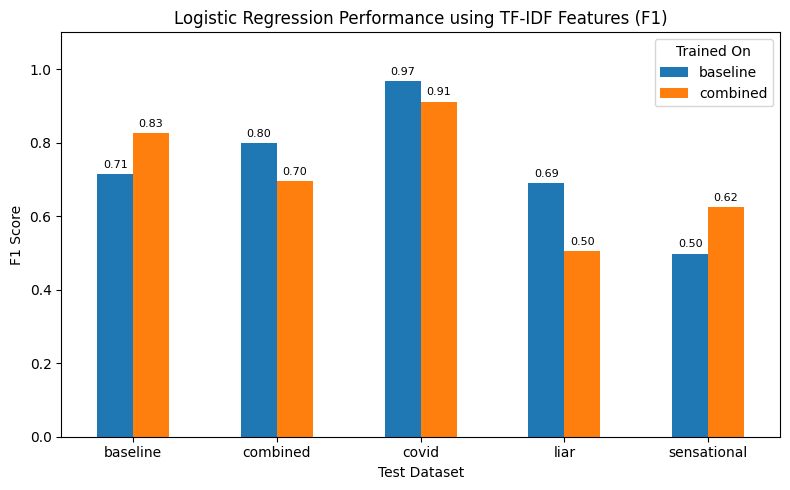

In [ ]:
import matplotlib.pyplot as plt

df = results_df.copy()

# Focus on Logistic Regression (cleaner story)
df_lr = df[df["model"] == "TF-IDF + Logistic Regression"]

pivot = df_lr.pivot(index="test_dataset", columns="train_dataset", values="f1")

ax = pivot.plot(kind="bar", figsize=(8,5))
plt.title("Logistic Regression Performance using TF-IDF Features (F1)")
plt.ylabel("F1 Score")
plt.xlabel("Test Dataset")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(title="Trained On")

# Add percentages above bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3, fontsize=8, color='black')

plt.tight_layout()
plt.show()

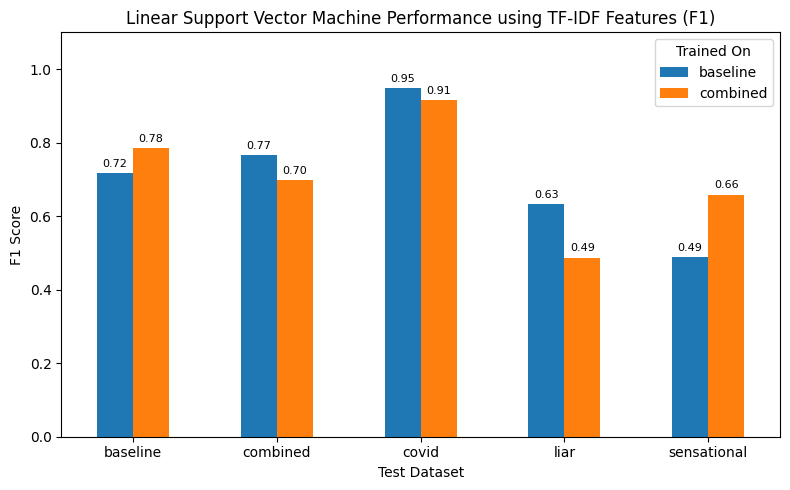

In [ ]:
df_rf = df[df["model"] == "TF-IDF + LinearSVC"]

pivot = df_rf.pivot(index="test_dataset", columns="train_dataset", values="f1")

ax = pivot.plot(kind="bar", figsize=(8,5))
plt.title("Linear Support Vector Machine Performance using TF-IDF Features (F1)")
plt.ylabel("F1 Score")
plt.xlabel("Test Dataset")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(title="Trained On")

# Add percentages above bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3, fontsize=8, color='black')

plt.tight_layout()
plt.show()

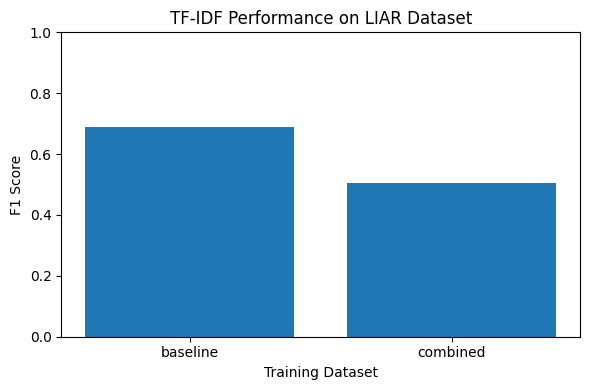

In [ ]:
liar_df = df_lr[df_lr["test_dataset"] == "liar"]

plt.figure(figsize=(6,4))
plt.bar(liar_df["train_dataset"], liar_df["f1"])
plt.title("TF-IDF Performance on LIAR Dataset")
plt.ylabel("F1 Score")
plt.xlabel("Training Dataset")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

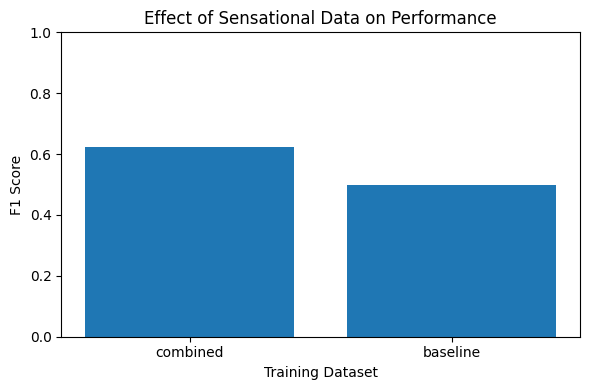

In [ ]:
sen_df = df_lr[df_lr["test_dataset"] == "sensational"]

plt.figure(figsize=(6,4))
plt.bar(sen_df["train_dataset"], sen_df["f1"])
plt.title("Effect of Sensational Data on Performance")
plt.ylabel("F1 Score")
plt.xlabel("Training Dataset")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

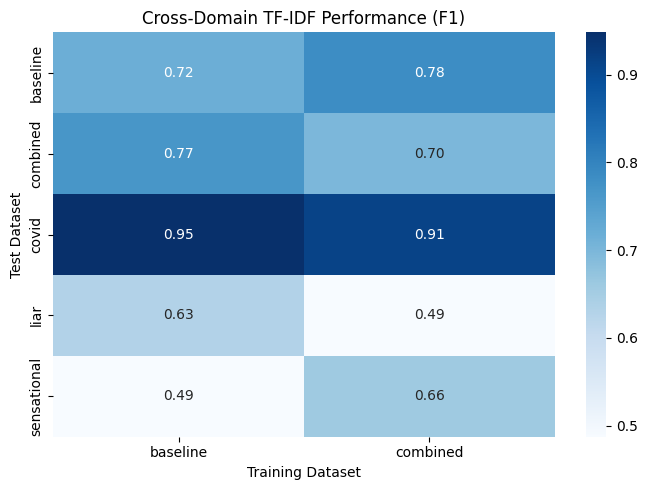

In [ ]:
import seaborn as sns

plt.figure(figsize=(7,5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Blues")
plt.title("Cross-Domain TF-IDF Performance (F1)")
plt.xlabel("Training Dataset")
plt.ylabel("Test Dataset")
plt.tight_layout()
plt.show()



---

Save Model

In [ ]:
# =========================
# Save trained TF-IDF models
# =========================

MODEL_OUT_DIR = "/content/drive/MyDrive/Senior_Project/02_Models/Saved_Models"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

def safe_model_name(name):
    return (
        name.replace(" ", "_")
            .replace("+", "plus")
            .replace("-", "")
            .replace("/", "_")
    )

for model_key, model in trained_tfidf_models.items():
    safe_name = safe_model_name(model_key)
    model_path = f"{MODEL_OUT_DIR}/{safe_name}.joblib"
    joblib.dump(model, model_path)
    print("Saved:", model_path)

Saved: /content/drive/MyDrive/Senior_Project/02_Models/Saved_Models/baseline_TFIDF_plus_Logistic_Regression.joblib
Saved: /content/drive/MyDrive/Senior_Project/02_Models/Saved_Models/baseline_TFIDF_plus_LinearSVC.joblib
Saved: /content/drive/MyDrive/Senior_Project/02_Models/Saved_Models/combined_TFIDF_plus_Logistic_Regression.joblib
Saved: /content/drive/MyDrive/Senior_Project/02_Models/Saved_Models/combined_TFIDF_plus_LinearSVC.joblib
